# Part A: Conceptual Understanding (Theory)




### **Q1. What are Supervised Learning Algorithms?**

Supervised learning algorithms are machine learning methods where
the model is trained using labeled data (input + correct output). The
model learns the relationship between input and output to make
predictions on new data. Examples include regression and
classification algorithms.

---

### **Q2. Difference between Regression vs Classification.**  
Regression predicts continuous values (e.g., house price, salary),
while classification predicts categorical labels (e.g., yes/no,
spam/not spam). Regression output is numeric, whereas
classification output is discrete classes.

---

### **Q3. Explain Simple Linear Regression**  
Simple Linear Regression is a technique used to model the
relationship between one independent variable (X) and one
dependent variable (y). It fits a straight line equation:
 **y=mx+c**
where m is slope and c is intercept.

---

### **Q4. Assumptions of Linear Regression**  
● Linear relationship between variables

● Independence of errors

● Constant variance (Homoscedasticity)

● No multicollinearity

● Errors are normally distributed

These assumptions ensure accurate and reliable predictions.

---

### **Q5. What is Bias–Variance Trade-Off?**  
Bias–Variance Trade-Off is the balance between underfitting and
overfitting.

● High bias → model too simple (underfitting)

● High variance → model too complex (overfitting)

Goal is to find a model that balances both for best
performance.

---

### **Q6. Overfitting vs Underfitting**

● Underfitting: Model is too simple and cannot capture
patterns (e.g., straight line on curved data)

● Overfitting: Model learns noise and performs well on training
but poorly on test data

Example: Polynomial regression with very high degree →
overfitting, while linear model on curved data → underfitting.

# Part B: Dataset Understanding & Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("RealEstate_HousePrice_Dataset_4200.csv")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (4200, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [4]:
df.isnull().sum()

,0
house_id,0
area_sqft,0
bedrooms,0
bathrooms,0
location_score,0
age_years,0
distance_city_km,0
lot_size_sqft,0
has_garage,0
has_pool,0


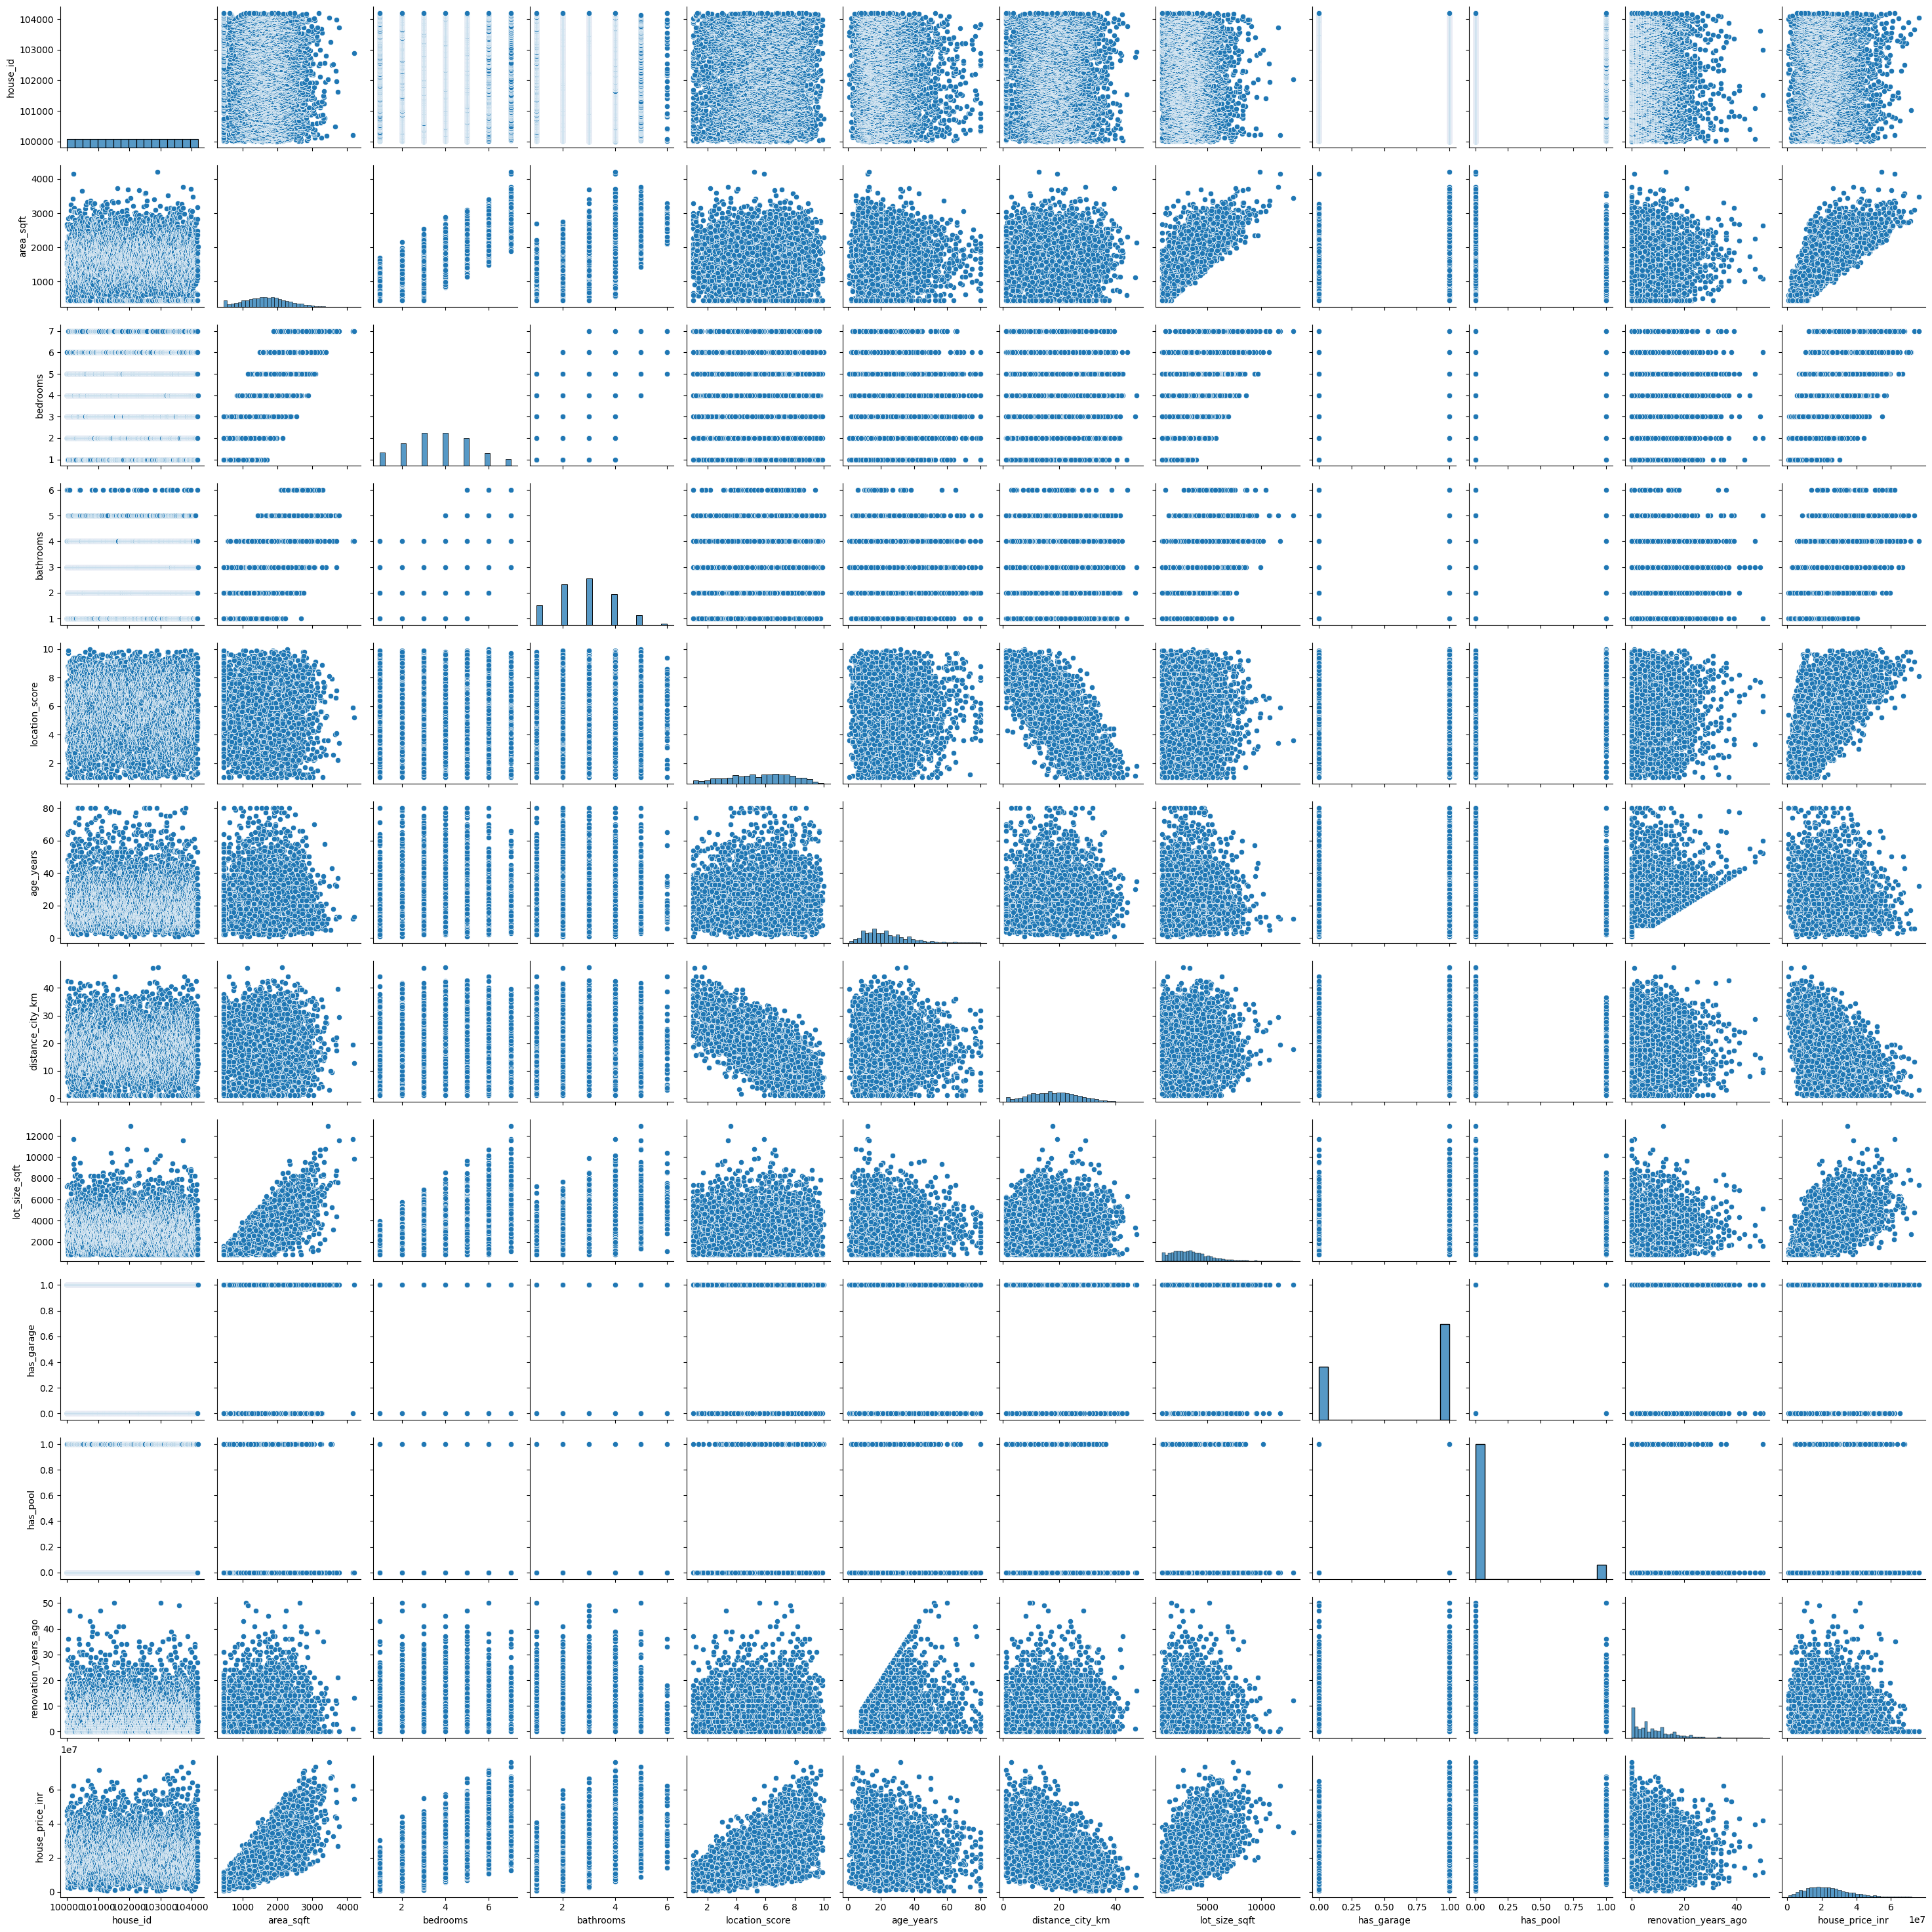

In [5]:
sns.pairplot(df)
plt.show()

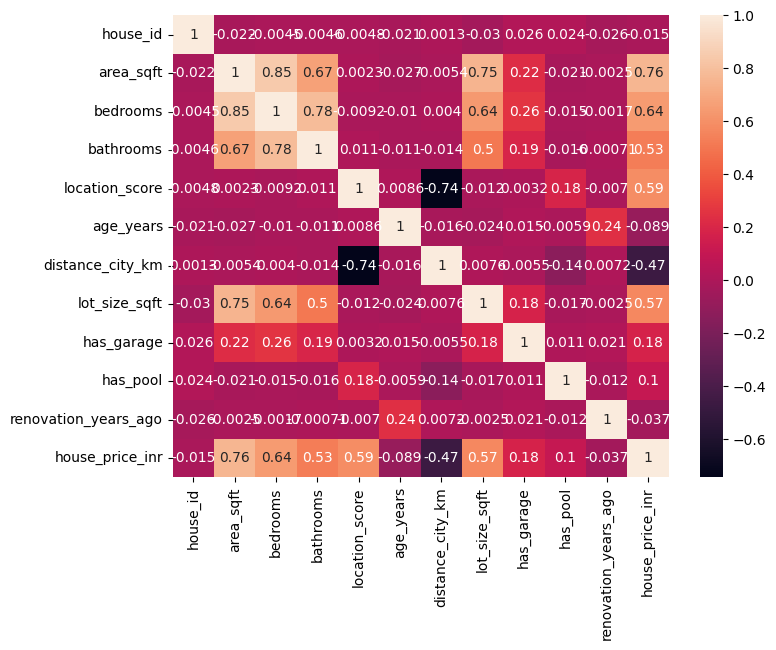

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [7]:
features = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
            'age_years', 'distance_city_km', 'lot_size_sqft',
            'has_garage', 'has_pool', 'renovation_years_ago']
target   = 'house_price_inr'

df[features]

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago
0,1973,5,4,7.6,23,11.9,5220,1,0,0
1,1560,3,3,6.3,13,15.8,3882,1,0,13
2,2071,4,3,5.8,9,21.1,4488,0,0,9
3,2640,5,3,7.7,12,7.9,3614,1,1,4
4,1498,3,3,3.8,15,24.0,2663,0,0,15
...,...,...,...,...,...,...,...,...,...,...
4195,1328,4,2,4.9,21,19.6,2606,1,0,21
4196,2363,6,4,6.9,53,24.9,4013,1,0,14
4197,632,2,2,4.5,27,19.4,1268,1,0,6
4198,450,2,2,7.5,26,11.6,800,0,0,9


In [8]:
X = df[features]
y = df[target]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

# Part C: Simple Linear Regression

In [10]:
X = df[['area_sqft']]
y = df['house_price_inr']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
print(f'Intercept: {model.intercept_:.2f}')
print(f'Coefficient: {model.coef_[0]:.2f}')

Intercept: -1163519.18
Coefficient: 14788.31


In [14]:
y_pred_slr = model.predict(X_test)

In [15]:
y_test

,house_price_inr
1743,36890986
2196,27836840
1728,15321534
3337,30812774
298,18194835
...,...
152,20918771
1948,44375916
2751,22099538
2148,22898162


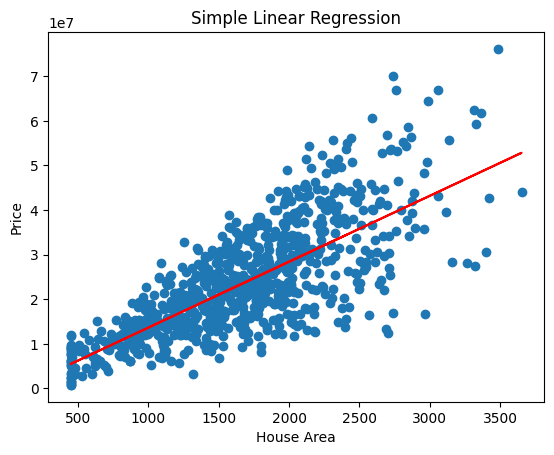

In [16]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_slr, color='red')
plt.xlabel("House Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()

In [17]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [14788.30611131]
Intercept: -1163519.1764186136


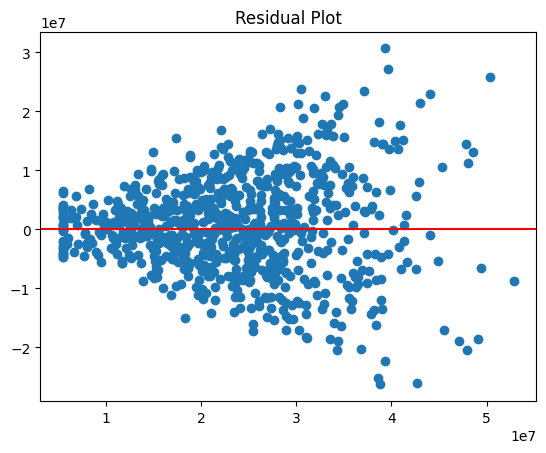

In [18]:
residuals = y_test - y_pred_slr

plt.scatter(y_pred_slr, residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

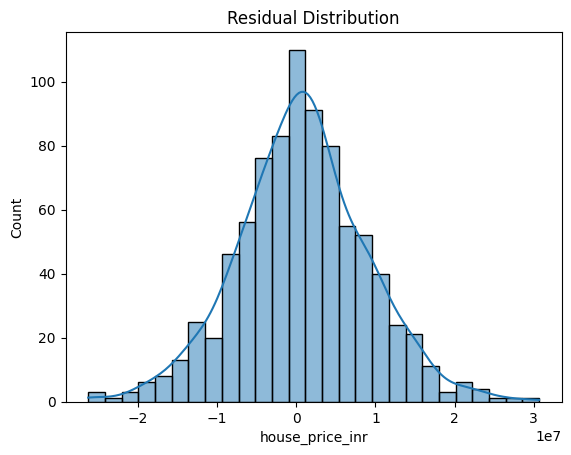

In [19]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Part D: Model Evaluation Metrics

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_slr = model.predict(X_test)

# 1. MAE
mae = mean_absolute_error(y_test, y_pred_slr)

# 2. MSE
mse = mean_squared_error(y_test, y_pred_slr)

# 3. RMSE
rmse = np.sqrt(mse)

# 4. R² Score
r2 = r2_score(y_test, y_pred_slr)

# 5. Adjusted R²
n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2)

MAE: 6294593.696131912
MSE: 66989260021849.47
RMSE: 8184696.696997969
R2 Score: 0.5625199587991578
Adjusted R2: 0.5619979062440257


#### **`Interpretation of Model Evaluation Metrics`**

#### 1. Mean Absolute Error (MAE)
MAE represents the average absolute difference between actual and predicted values.  
It tells us how much error the model makes on average in the same unit as the target variable.  
**Lower MAE indicates better model performance.**

---

#### 2. Mean Squared Error (MSE)
MSE calculates the average of squared differences between actual and predicted values.  
It penalizes larger errors more heavily due to squaring.  
**Lower MSE indicates better performance, but values are in squared units.**

---

#### 3. Root Mean Squared Error (RMSE)
RMSE is the square root of MSE and brings the error back to the original unit.  
It is useful for understanding the model error in real-world terms.  
**Lower RMSE indicates better model accuracy.**

---

#### 4. R² Score (Coefficient of Determination)
R² measures how well the model explains the variability of the target variable.  
Its value ranges from 0 to 1.  
- R² = 1 → Perfect prediction  
- R² = 0 → Model performs like a mean prediction  
**Higher R² indicates better model performance.**

---

#### 5. Adjusted R² Score
Adjusted R² improves R² by adjusting for the number of features used in the model.  
It penalizes unnecessary features that do not improve the model.  
**Higher Adjusted R² indicates a better and more reliable model.**

---


# Part E: Multiple Linear Regression

In [23]:
X = df[features]
y = df[target]

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X, y, test_size=0.2, random_state=18)

model_mlr = LinearRegression()
model_mlr.fit(X_train_mlr, y_train_mlr)

coef = pd.DataFrame({"Features": features, "Coefficient": model_mlr.coef_})
coef = coef.sort_values("Coefficient", ascending=False)

In [24]:
print("Coefficients:")
print(coef.to_string(index=False))
print(f"Intercept (beta_0): Rs. {model_mlr.intercept_:,.2f}")

Coefficients:
            Features   Coefficient
      location_score  3.083386e+06
            has_pool  3.847229e+05
            bedrooms  1.968428e+05
           bathrooms  1.845988e+05
          has_garage  1.735200e+05
           area_sqft  1.394540e+04
       lot_size_sqft  5.565966e+01
renovation_years_ago -2.711694e+04
           age_years -6.669456e+04
    distance_city_km -1.029450e+05
Intercept (beta_0): Rs. -14,814,258.43


In [25]:
y_pred_mlr = model_mlr.predict(X_test_mlr)

mae_mlr  = mean_absolute_error(y_test_mlr, y_pred_mlr)
mse_mlr  = mean_squared_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr   = r2_score(y_test_mlr, y_pred_mlr)

n2 = len(y_test_mlr)
p2 = X_test_mlr.shape[1]
adj_r2_mlr = 1 - (1 - r2_mlr) * (n2 - 1) / (n2 - p2 - 1)

print("  Multiple Linear Regression — Test Metrics")
print(f"  MAE      : {mae_mlr:,.2f}")
print(f"  MSE      : {mse_mlr:,.2f}")
print(f"  RMSE     : {rmse_mlr:,.2f}")
print(f"  R² Score : {r2_mlr:.4f}")
print(f"  Adj R²   : {adj_r2_mlr:.4f}")

  Multiple Linear Regression — Test Metrics
  MAE      : 2,518,553.71
  MSE      : 11,259,867,467,824.33
  RMSE     : 3,355,572.60
  R² Score : 0.9247
  Adj R²   : 0.9238


In [26]:
mae_slr = mean_absolute_error(y_test, y_pred_slr)
mse_slr = mean_squared_error(y_test, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_test, y_pred_slr)

# Multiple Linear Regression
mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)


print("Simple Linear Regression")
print("MAE:", mae_slr)
print("RMSE:", rmse_slr)
print("R2:", r2_slr)

print("\nMultiple Linear Regression")
print("MAE:", mae_mlr)
print("RMSE:", rmse_mlr)
print("R2:", r2_mlr)

Simple Linear Regression
MAE: 6294593.696131912
RMSE: 8184696.696997969
R2: 0.5625199587991578

Multiple Linear Regression
MAE: 2518553.708486457
RMSE: 3355572.5990990466
R2: 0.9247183530039123


#### **`Comparison: Simple vs Multiple Linear Regression`**

#### Simple Linear Regression
- Uses only one feature (e.g., house area)
- Limited ability to capture complex relationships
- Higher error and lower accuracy in most real-world cases

#### Multiple Linear Regression
- Uses multiple features (area, bedrooms, bathrooms, location, etc.)
- Captures more information from data
- Generally gives:
  - Lower MAE, MSE, RMSE
  - Higher R² score

---

#### Why Performance Improves?

- More features = more information about house price
- Model learns better relationships
- Reduces underfitting

---

#### When Performance Can Degrade?

- Too many irrelevant features → noise increases
- Multicollinearity (features highly correlated)
- Overfitting (model learns training data too well)

---


# Part F: Polynomial Regression

In [45]:
from sklearn.preprocessing import PolynomialFeatures

In [46]:
X_poly_feature = df[['area_sqft']]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly_feature, y, test_size=0.2, random_state=42)

for d in [2, 3]:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train_p)
    X_test_poly = poly.transform(X_test_p)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_p)

    y_pred = model.predict(X_test_poly)

    print(f"\n--- Polynomial Regression Degree {d} ---")
    print("MAE:", mean_absolute_error(y_test_p, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test_p, y_pred)))
    print("R2:", r2_score(y_test_p, y_pred))


--- Polynomial Regression Degree 2 ---
MAE: 6292394.561281703
RMSE: 8183089.094113433
R2: 0.5626917978136476

--- Polynomial Regression Degree 3 ---
MAE: 6289615.314592109
RMSE: 8181382.291611443
R2: 0.5628742034759397


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


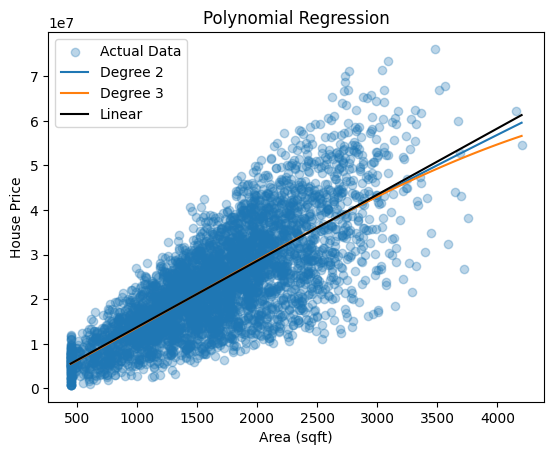

In [49]:
plt.scatter(X_poly_feature, y, alpha=0.3, label='Actual Data')

X_range = np.linspace(X_poly_feature.min(), X_poly_feature.max(), 100).reshape(-1,1)

for d in [2, 3]:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_poly_feature)

    model = LinearRegression()
    model.fit(X_poly, y)

    plt.plot(X_range, model.predict(poly.transform(X_range)), label=f'Degree {d}')

linear = LinearRegression()
linear.fit(X_poly_feature, y)

X_range = np.linspace(X_poly_feature.min(), X_poly_feature.max(), 100).reshape(-1,1)
plt.plot(X_range, linear.predict(X_range), color='black', label='Linear')

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

## => Overfitting vs Underfitting

###  Underfitting
- Model is too simple
- Cannot capture pattern in data
- High training error and high testing error
- Example: Linear regression on curved data

---

###  Good Fit
- Model captures pattern correctly
- Low training and testing error
- Balanced model performance

---

###  Overfitting
- Model is too complex
- Learns noise instead of pattern
- Very low training error but high testing error
- Example: High-degree polynomial

---

## -> Signs to Identify

| Case | Training Error | Testing Error | Meaning |
|------|--------------|--------------|--------|
| Underfitting | High | High | Model too simple |
| Good Fit | Low | Low | Best model |
| Overfitting | Very Low | High | Model too complex |



# **Part G: Gradient Descent Optimization**

In [33]:
X_bgd = X_train[['area_sqft']].values
y_bgd = y_train.values

m = len(X_bgd)
theta0 = 0
theta1 = 0
learning_rate = 0.00001
iterations = 1000

for i in range(iterations):
    y_pred = theta0 + theta1 * X_bgd.flatten()

    error = y_pred - y_bgd

    # gradients
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X_bgd.flatten())

    # update
    theta0 = theta0 - learning_rate * d_theta0
    theta1 = theta1 - learning_rate * d_theta1

print("Theta0:", theta0)
print("Theta1:", theta1)

Theta0: nan
Theta1: nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_8838/2634432119.py:21: RuntimeWarning: invalid value encountered in scalar subtract
  theta1 = theta1 - learning_rate * d_theta1
